(1e-08, 3.0)

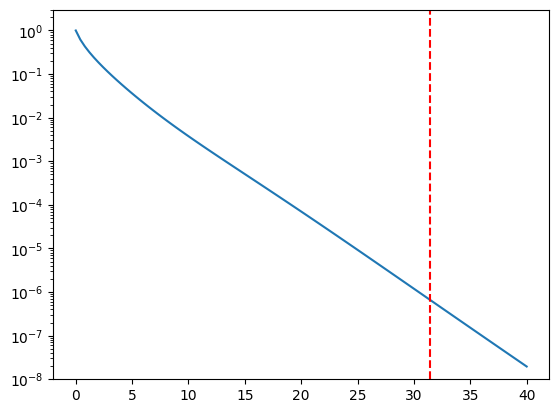

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import DiagonalGate, QFTGate, StatePreparation, UnitaryGate
from qiskit.quantum_info import Statevector
from scipy.linalg import expm
from lchs import spectral_diff_adv

n_qubits = 5

D = 0.1
N = 2**n_qubits
L = 2 * np.pi               
time = 40  
x = np.linspace(0, L, N, endpoint=False)
dx = L / N

# Parameters
c_L = 0.0
c_H = 0.2
#c = c_H*np.ones_like(x)
c = -4*(c_H -c_L)/L**2 *x**2 + 4*(c_H -c_L)/L *x 
#cx = np.zeros_like(x)
cx = -8*(c_H - c_L)/L**2 *x + 4*(c_H -c_L)/L 

a = 0.0
a_x = a*np.ones_like(x)

# Initial State: Gaussian centered in the middle
sigma = L/20
state = np.exp(-0.5*((x-dx*N/4)/sigma)**2)
state = state / np.linalg.norm(state)

ts = np.linspace(0, time, 100)

plt.figure()
norms = []

for t in ts:
    spectral = spectral_diff_adv(n_qubits, t, cx, c, D, L, a_x, init_state=state, normalize=False)
    norm = np.linalg.norm(spectral)**2
    norms.append(norm)
plt.semilogy(ts, norms, '-', label='Spectral')

Tau_c = L/c_H
#Tau_r = 1/a
#Tau_D = L**2 / D
plt.axvline(Tau_c, color='r', linestyle='--', label=r'$\tau_c$')
#plt.axvline(Tau_r, color='g', linestyle='--', label=r'$\tau_r$')
#plt.axvline(Tau_D, color='k', linestyle='--', label=r'$\tau_D$')
plt.ylim(1e-8,1e0+2)

/home/alessandro/documents/adr_qft/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/alessandro/documents/adr_qft/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


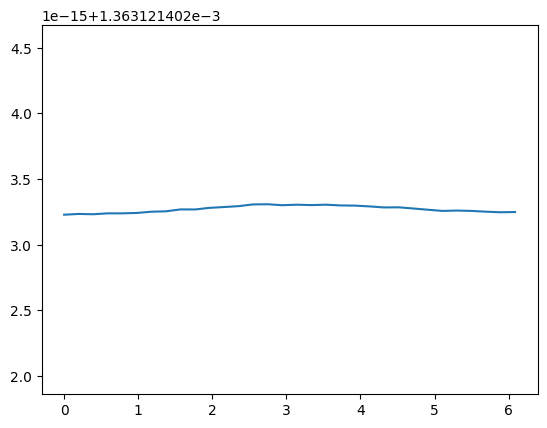

In [6]:
plt.plot(x, spectral, label='Final State')